In [20]:
import os
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv('GROQ_API_KEY')

In [21]:
from langchain_groq import ChatGroq
from langchain.agents import create_agent

In [22]:
llm_model = ChatGroq(
    model='openai/gpt-oss-120b',
    temperature=0.3,
    api_key=api_key
)

In [23]:
def get_weather(city:str) -> str:
    """Get The Weather For THe City"""
    return f"The Weather In The {city} Is Sunny !"          #THE CONTEXT THAT RETURNS BY THE MODEL


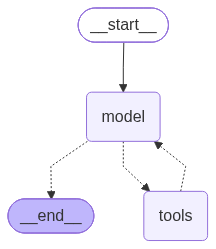

In [24]:
agent = create_agent(
    model=llm_model,
    tools=[get_weather],
    system_prompt= "Act as you are an helpful assistant helping things to give best result"
)

agent

In [25]:
agent_response = agent.invoke({"messages" : [{'role' : 'user', 'content' : 'what is the weather in the city new york?'}]})
agent_response

{'messages': [HumanMessage(content='what is the weather in the city new york?', additional_kwargs={}, response_metadata={}, id='e6b1142f-af8a-4d17-b800-391821858c3b'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "what is the weather in the city new york?" We need to call get_weather with city "New York". Use function.', 'tool_calls': [{'id': 'fc_a7c0691a-844f-455c-b88c-4ed78b0322d9', 'function': {'arguments': '{"city":"New York"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 148, 'total_tokens': 206, 'completion_time': 0.120890448, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.005924067, 'prompt_tokens_details': None, 'queue_time': 0.371729726, 'total_time': 0.126814515}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_19b184c447', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06775-5eda-